In [1]:
!pip install -q datasets transformers evaluate scikit-learn

import numpy as np, pandas as pd
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer

ds = load_dataset("Yelp/yelp_review_full")
train = pd.DataFrame(ds["train"].shuffle(seed=42).select(range(20000)))
test = pd.DataFrame(ds["test"].shuffle(seed=42).select(range(5000)))
tr, val = train_test_split(train, test_size=0.1, random_state=42, stratify=train["label"])

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def to_ds(df):
    d = Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
    return d.map(lambda b: tokenizer(b["text"], truncation=True, max_length=256), batched=True)

tr_ds, val_ds, te_ds = to_ds(tr), to_ds(val), to_ds(test)
print(tr_ds, val_ds, te_ds)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  299MB            

yelp_review_full/train-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

yelp_review_full/test-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 23.5MB            

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18000
}) Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
}) Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [2]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

def compute_metrics(eval_pred):
    logits, y = eval_pred
    p = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(y, p), "macro_f1": f1_score(y, p, average="macro")}

args = TrainingArguments(
    output_dir="distilbert-yelp",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=tr_ds, eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.039204,0.955785,0.593000,0.577375
2,0.823699,0.913818,0.613500,0.611719
3,0.691306,0.966081,0.608000,0.607115


TrainOutput(global_step=1689, training_loss=0.8290278975112401, metrics={'train_runtime': 333.0291, 'train_samples_per_second': 162.148, 'train_steps_per_second': 5.072, 'total_flos': 3576811115520000.0, 'train_loss': 0.8290278975112401, 'epoch': 3.0})

In [4]:
out = trainer.predict(te_ds)
preds = np.argmax(out.predictions, axis=-1)
print("DistilBERT Accuracy:", accuracy_score(test["label"], preds))
print("DistilBERT Macro F1:", f1_score(test["label"], preds, average="macro"))

Epoch,Training Loss,Validation Loss


DistilBERT Accuracy: 0.5628
DistilBERT Macro F1: 0.5582205386555327


In [5]:
from sklearn.metrics import classification_report, confusion_matrix

val_out = trainer.predict(val_ds)
val_preds = np.argmax(val_out.predictions, axis=-1)
print("VAL  acc/F1:", accuracy_score(val["label"], val_preds),
      f1_score(val["label"], val_preds, average="macro"))
print("TEST acc/F1:", accuracy_score(test["label"], preds),
      f1_score(test["label"], preds, average="macro"))

print("\nTest class counts (true):", np.bincount(test["label"], minlength=5))
print("Test class counts (pred):", np.bincount(preds, minlength=5))
print()
print(classification_report(test["label"], preds,
      target_names=["1★", "2★", "3★", "4★", "5★"]))
print(confusion_matrix(test["label"], preds))

Epoch,Training Loss,Validation Loss


VAL  acc/F1: 0.569 0.5624314081904123
TEST acc/F1: 0.5628 0.5582205386555327

Test class counts (true): [1032  986  974 1055  953]
Test class counts (pred): [1054  786 1000 1007 1153]

              precision    recall  f1-score   support

          1★       0.72      0.74      0.73      1032
          2★       0.52      0.42      0.46       986
          3★       0.45      0.46      0.46       974
          4★       0.48      0.46      0.47      1055
          5★       0.62      0.75      0.67       953

    accuracy                           0.56      5000
   macro avg       0.56      0.56      0.56      5000
weighted avg       0.56      0.56      0.56      5000

[[760 194  59   8  11]
 [225 410 290  51  10]
 [ 44 149 451 275  55]
 [ 16  24 165 483 367]
 [  9   9  35 190 710]]


In [6]:
ev = trainer.evaluate(val_ds)
print("trainer.evaluate:", ev)
print("labels match:", np.array_equal(val_out.label_ids, val["label"].values))

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
0,No log,1.005933,0.569000,0.562431


trainer.evaluate: {'eval_loss': 1.0059325695037842, 'eval_accuracy': 0.569, 'eval_macro_f1': 0.5624314081904123}
labels match: True


In [8]:
!pip install -q datasets transformers evaluate scikit-learn

import numpy as np, pandas as pd
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer

ds = load_dataset("Yelp/yelp_review_full")
train = pd.DataFrame(ds["train"].shuffle(seed=42).select(range(20000)))
test = pd.DataFrame(ds["test"].shuffle(seed=42).select(range(5000)))
tr, val = train_test_split(train, test_size=0.1, random_state=42, stratify=train["label"])

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def to_ds(df):
    d = Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
    return d.map(lambda b: tokenizer(b["text"], truncation=True, max_length=256), batched=True)

tr_ds, val_ds, te_ds = to_ds(tr), to_ds(val), to_ds(test)
print(tr_ds, val_ds, te_ds)

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18000
}) Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
}) Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [9]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

def compute_metrics(eval_pred):
    logits, y = eval_pred
    p = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(y, p), "macro_f1": f1_score(y, p, average="macro")}

args = TrainingArguments(
    output_dir="distilbert-yelp",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=tr_ds, eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.033061,0.963455,0.595000,0.578827
2,0.821173,0.919062,0.618000,0.616448
3,0.685718,0.963742,0.611000,0.610212


TrainOutput(global_step=1689, training_loss=0.8245833573643451, metrics={'train_runtime': 342.3973, 'train_samples_per_second': 157.712, 'train_steps_per_second': 4.933, 'total_flos': 3576811115520000.0, 'train_loss': 0.8245833573643451, 'epoch': 3.0})

In [10]:
out = trainer.predict(te_ds)
preds = np.argmax(out.predictions, axis=-1)
print("DistilBERT Accuracy:", accuracy_score(test["label"], preds))
print("DistilBERT Macro F1:", f1_score(test["label"], preds, average="macro"))

DistilBERT Accuracy: 0.6078
DistilBERT Macro F1: 0.6083538170346151


Acc/F1: 0.6078 0.6083538170346151
              precision    recall  f1-score   support

          1★       0.77      0.72      0.74      1032
          2★       0.54      0.58      0.56       986
          3★       0.54      0.51      0.53       974
          4★       0.52      0.52      0.52      1055
          5★       0.67      0.71      0.69       953

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.61      0.61      0.61      5000

[[742 242  32   7   9]
 [187 568 186  38   7]
 [ 22 200 500 226  26]
 [ 12  33 171 550 289]
 [  6   5  30 233 679]]
Errors off by exactly 1 star: 1734 of 1961


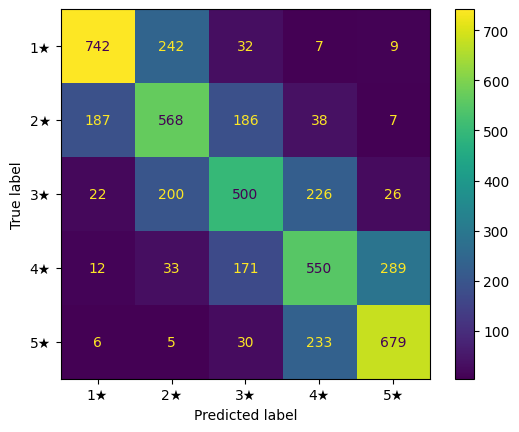

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

out = trainer.predict(te_ds)
preds = np.argmax(out.predictions, axis=-1)
names = ["1★", "2★", "3★", "4★", "5★"]

print("Acc/F1:", accuracy_score(test["label"], preds),
      f1_score(test["label"], preds, average="macro"))
print(classification_report(test["label"], preds, target_names=names))

cm = confusion_matrix(test["label"], preds)
print(cm)
off1 = sum(cm[i][j] for i in range(5) for j in range(5) if abs(i - j) == 1)
errors = cm.sum() - np.trace(cm)
print("Errors off by exactly 1 star:", off1, "of", errors)

ConfusionMatrixDisplay.from_predictions(test["label"], preds, display_labels=names)